## 温泉の泉質データの分析アルゴリズム設計

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import japanize_matplotlib

python(78851) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [128]:
df1 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/岩手.xls",
    engine="xlrd"   # .xls の場合
)

df2 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/宮城.xls",
    engine="xlrd"   # .xls の場合
)

df3 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/山形.xls",
    engine="xlrd"   # .xls の場合
)

df4 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/青森.xls",
    engine="xlrd"   # .xls の場合
)

df5 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/秋田.xls",
    engine="xlrd"   # .xls の場合
)

df6 = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/福島.xls",
    engine="xlrd"   # .xls の場合
)

df = pd.concat([df1,df2,df3,df4,df5,df6],axis=0)
df.head()


,都道府県名,所在地,東経（゜）,東経（′）,東経（″),北緯（゜）,北緯（′）,北緯（″),標高（ｍ）,水源種別,...,HBO2,dis.O2,free H2S,free CO2,T-CO2,T-As,T-Hg,T-P,T-B,Ｅｈ
0,岩手県,盛岡市南方約8km,NaN,NaN,NaN,NaN,NaN,NaN,NaN,井戸,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,岩手県,NaN,140.0,53.0,20.0,39.0,12.0,40.0,650.0,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,岩手県,NaN,140.0,46.0,30.0,38.0,58.0,40.0,NaN,湧泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,650.0,湧泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,650.0,井戸,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
len(df)

4082

In [130]:
df.columns

Index(['都道府県名', '所在地', '東経（゜）', '東経（′）', '東経（″)', '北緯（゜）', '北緯（′）', '北緯（″)',
       '標高（ｍ）', '水源種別',
       ...
       'HBO2', 'dis.O2', 'free H2S', 'free CO2', 'T-CO2', 'T-As', 'T-Hg',
       'T-P', 'T-B', 'Ｅｈ'],
      dtype='object', length=152)

In [132]:
df['ID'] = (
    df['東経（゜）'].astype(str) + '_' +
    df['東経（′）'].astype(str) + '_' +
    df['東経（″)'].astype(str) + '_' +
    df['北緯（゜）'].astype(str) + '_' +
    df['北緯（′）'].astype(str) + '_' +
    df['北緯（″)'].astype(str) + '_' +
    df.index.astype(str)
)

In [133]:
l = df.isna().sum()
l[:10]


都道府県名       0
所在地       329
東経（゜）    2440
東経（′）    2440
東経（″)    2440
北緯（゜）    2440
北緯（′）    2440
北緯（″)    2440
標高（ｍ）    3979
水源種別        0
dtype: int64

In [134]:
df2 = df.dropna(subset=['所在地'])
df.isna().sum().sort_values(ascending=True)[20:30]

北緯（″)       2440
北緯（′）       2440
北緯（゜）       2440
Ｋ＋          2527
ｆｒｅｅ　ＣＯ２    2586
ＮＨ４＋        2684
ＫＭｎＯ４消費     2916
ＳｉO２        2963
Ｔ−ＣＯ２       3021
ＮＯ２−        3073
dtype: int64

In [135]:
df1.columns

Index(['都道府県名', '所在地', '東経（゜）', '東経（′）', '東経（″)', '北緯（゜）', '北緯（′）', '北緯（″)',
       '標高（ｍ）', '水源種別', '利用目的', '井戸深度', '採水標高', '気温', '水温', '湧出量', '水質（外観臭味）',
       'ｐＨ', 'ＲｐＨ', 'Ｒｎ(マッヘ)', '比重', '密度', '蒸発残留物', '電気伝導度', '水比抵抗', 'ＥＨ',
       'ＫＭｎＯ４消費', 'Ｈ＋', 'Ｌｉ＋', 'Na＋', 'Ｋ＋', 'Ｒｂ＋', 'Ｃｓ＋', 'ＮＨ４＋', 'Ｍｇ２＋',
       'Ｃａ２＋', 'Ｓｒ２＋', 'Ｂａ２＋', 'Ａｌ３＋', 'Ｍｎ２＋', 'Ｆｅ２＋', 'Ｆｅ３＋', 'Ｔ−Ｆｅ', 'Ｃｕ２＋',
       'Ｚｎ２＋', 'Ｐｂ２＋', 'Ｓｉ４＋', 'Ｆ−', 'Ｃｌ−', 'Ｂｒ−', 'I−', 'OH−', 'ＮＯ２−', 'ＮＯ３−',
       'ＨＳ−', 'Ｓ２Ｏ３2−', 'ＨＳＯ４−', 'ＳＯ４２−', 'ＳＯ３２−', 'Ｈ２ＰＯ４−', 'ＨＰＯ４２−', 'ＰＯ４３−',
       'ＨＣＯ３−', 'ＣＯ３２−', 'ＨＳｉＯ３−', 'ＳｉＯ３２−', 'ＢＯ２−', 'Ｈ２ＳＯ４', 'Ｈ３ＰＯ４', 'ＨＡｓＯ２',
       'ＡｓＯ２-', 'ＳｉO２', 'Ｈ２ＳｉＯ３', 'ＨＢＯ２', 'ｄｉｓ．０２', 'ｆｒｅｅ　Ｈ２Ｓ', 'ｆｒｅｅ　ＣＯ２',
       'Ｔ−ＣＯ２', 'Ｔ−Ａｓ', 'Ｔ−Ｈｇ', 'Ｔ−Ｐ', 'Ｔ−Ｂ', '単位', '調査日', '文献名'],
      dtype='object')

In [136]:
df2 = df.dropna(subset=['所在地'])
df.isna().mean().sort_values(ascending=False)

major_cols = [
    'ｐＨ', '水温',
    'Na＋', 'Ｋ＋', 'Ｃａ２＋', 'Ｍｇ２＋',
    'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−','ＮＨ４＋'
]

df[major_cols].isna().sum(),len(df)

(ｐＨ        848
 水温        411
 Na＋      2434
 Ｋ＋       2527
 Ｃａ２＋     1313
 Ｍｇ２＋     2252
 Ｃｌ−       880
 ＳＯ４２−    1369
 ＨＣＯ３−    1290
 ＮＨ４＋     2684
 dtype: int64,
 4082)

In [137]:
df.isna().sum()

都道府県名       0
所在地       329
東経（゜）    2440
東経（′）    2440
東経（″)    2440
         ... 
T-Hg     4082
T-P      4006
T-B      4082
Ｅｈ       4062
ID          0
Length: 153, dtype: int64

In [138]:
max_na = 2500
df_filtered = df2.loc[:, df2.isna().sum() <= max_na]
df_filtered

,都道府県名,所在地,東経（゜）,東経（′）,東経（″),北緯（゜）,北緯（′）,北緯（″),水源種別,利用目的,...,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,ｆｒｅｅ ＣＯ２,調査日,文献名,ID
0,岩手県,盛岡市南方約8km,NaN,NaN,NaN,NaN,NaN,NaN,井戸,ガス井,...,0.27,16.2,16.6,1.1,7.0,200.0,NaN,NaT,本邦天然ガス鉱床の地質学的研究，地調報告，1956,nan_nan_nan_nan_nan_nan_0
3,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,湧泉,温泉・鉱泉,...,0.20,7.65,450.0,194.0,1210.0,204.0,36.8,1977-09-15 00:00:00,夏油温泉の微量化学成分について，温泉科学，1979,140.0_53.0_20.0_39.0_12.0_40.0_3
4,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,井戸,温泉・鉱泉,...,0.29,5.95,510.0,163.0,1375.0,170.0,53.2,1978-07-14 00:00:00,夏油温泉の微量化学成分について，温泉科学，1979,140.0_53.0_20.0_39.0_12.0_40.0_4
5,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,湧泉,温泉・鉱泉,...,0.10,64.5,430.0,1923.0,590.0,538.0,125.0,1977-09-15 00:00:00,夏油温泉の微量化学成分について，温泉科学，1979,140.0_53.0_20.0_39.0_12.0_40.0_5
6,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,湧泉,温泉・鉱泉,...,1.42,53.0,390.0,1705.0,560.0,483.0,139.3,1977-09-15 00:00:00,夏油温泉の微量化学成分について，温泉科学，1979,140.0_53.0_20.0_39.0_12.0_40.0_6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,福島県,福島県いわき市渡辺町,140.0,49.0,11.0,36.0,57.0,27.0,湧泉,温泉・鉱泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,新潟地熱資源図説明書，地質調査所，1993,140.0_49.0_11.0_36.0_57.0_27.0_719
720,福島県,福島県いわき市泉町下川,140.0,50.0,41.0,36.0,56.0,29.0,井戸,温泉・鉱泉,...,NaN,18.1,29.5,497.1,98.8,425.4,NaN,NaN,新潟地熱資源図説明書，地質調査所，1993,140.0_50.0_41.0_36.0_56.0_29.0_720
721,福島県,福島県いわき市泉町下川畑中,140.0,51.0,40.0,36.0,56.0,31.0,不明,温泉・鉱泉,...,NaN,NaN,102.5,105.0,98.2,358.5,NaN,NaN,新潟地熱資源図説明書，地質調査所，1993,140.0_51.0_40.0_36.0_56.0_31.0_721
722,福島県,福島県いわき市泉町下皮大畑,140.0,51.0,59.0,36.0,55.0,3.0,不明,温泉・鉱泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,新潟地熱資源図説明書，地質調査所，1993,140.0_51.0_59.0_36.0_55.0_3.0_722


In [139]:
df_filtered.columns

Index(['都道府県名', '所在地', '東経（゜）', '東経（′）', '東経（″)', '北緯（゜）', '北緯（′）', '北緯（″)',
       '水源種別', '利用目的', '井戸深度', '水温', '湧出量', 'ｐＨ', 'Na＋', 'Ｋ＋', 'ＮＨ４＋', 'Ｍｇ２＋',
       'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−', 'ｆｒｅｅ　ＣＯ２', '調査日', '文献名', 'ID'],
      dtype='object')

In [140]:
df_filtered['利用目的'].unique()

df_use = df_filtered[['水源種別', '利用目的', '水温', 'ｐＨ', 'ＮＨ４＋', 'Ｍｇ２＋',
       'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−','ID']].dropna()


In [141]:
len(df_use)

277

In [142]:
df_use

,水源種別,利用目的,水温,ｐＨ,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,ID
3,湧泉,温泉・鉱泉,48,7.0,0.20,7.65,450.00,194.00,1210.0,204.0,140.0_53.0_20.0_39.0_12.0_40.0_3
4,井戸,温泉・鉱泉,67,6.9,0.29,5.95,510.00,163.00,1375.0,170.0,140.0_53.0_20.0_39.0_12.0_40.0_4
5,湧泉,温泉・鉱泉,35,7.0,0.10,64.5,430.00,1923.00,590.0,538.0,140.0_53.0_20.0_39.0_12.0_40.0_5
6,湧泉,温泉・鉱泉,45,6.7,1.42,53.0,390.00,1705.00,560.0,483.0,140.0_53.0_20.0_39.0_12.0_40.0_6
7,湧泉,温泉・鉱泉,52.5,6.6,1.44,49.0,360.00,1526.00,515.0,446.0,140.0_53.0_20.0_39.0_12.0_40.0_7
...,...,...,...,...,...,...,...,...,...,...,...
416,坑道,坑道湧水,21,6.6,0.45,98,233.00,4180.00,10.0,67.0,nan_nan_nan_nan_nan_nan_416
469,井戸,用水,14.5,6.35,0.01,14.8,54.80,18.20,74.9,3.1,nan_nan_nan_nan_nan_nan_469
474,井戸,用水,18,7.8,0.01,6.6,6.30,1.80,1.9,5.23,nan_nan_nan_nan_nan_nan_474
477,井戸,用水,13.5,6.25,0.01,9.09,9.48,4.88,15.4,1.78,nan_nan_nan_nan_nan_nan_477


/Users/yoshizawakazuki/.pyenv/versions/3.12.8/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


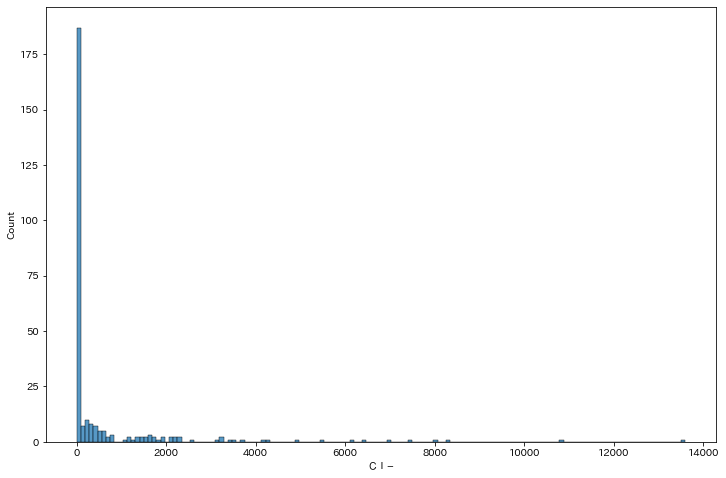

In [143]:
plt.figure(figsize=(12,8))
sns.histplot(x='Ｃｌ−',data=df_use)
plt.show()

In [144]:
df_use['ＳＯ４２−'].unique()

array([1210.0, 1375.0, 590.0, 560.0, 515.0, 485.0, 625.0, 654.0, 603.0,
       570.0, 660.0, 635.0, 495.0, 418.0, 152.0, 232.0, 91.8, 95.5, 101.0,
       338.0, 32.5, 1510.0, 9.96, 63.3, 14.6, 768.0, 78.9, 257.0, 210.0,
       301.0, 594.0, 391.0, 54.9, 26.8, 9.0, 14.7, 5.0, 44.6, 0.0, 1.0,
       2.0, 4.0, 44.4, 19.4, 27.1, 27.4, 7.0, 18.8, 32.2, 32.0, 7.7, 22.8,
       24.2, 93.0, 14.2, 45.9, 10.0, 22.7, 15.6, 28.0, 49.6, 23.4, 31.3,
       61.3, 7.8, 3.2, 32.8, 4.8, 1540.0, 41.7, 13, 16, 14, 18, 20, 21,
       27, 39, 72, 1130, 4.5, 9.1, 1.4, 1.5, 8.5, 9.7, 16.1, 15.2, 0.9,
       22.2, 17, 30, 8, 2.2, 5.5, 92, 76, 3.8, 14.8, 1.7, 2.9, 13.2, 2.1,
       1.2, 3.3, 0.8, 18.9, 0.2, 2.5, 17.7, 11.9, 3.7, 17.3, 10.7, 23.5,
       6.6, 28.3, '<0.01', 0.41, 4.1, 9.5, 8.6, 10.3, 6.2, 0.78, 32.4,
       135.8, 151, 145.1, 148.6, 2.88, 157.6, 160.1, 117.7, 125.1, 0.21,
       143.6, 4.21, 2.45, 49.8, 149, 1430, 1700, 5.68, 734, 212, 184, 181,
       47.5, 121, 15, 127, 2630, 1610, 500, 1250, 

In [145]:
df_use['ＳＯ４２−'] = pd.to_numeric(df_use['ＳＯ４２−'], errors='coerce')
df_use = df_use.dropna()

In [146]:
df_use[['水温', 'ｐＨ', 'ＮＨ４＋', 'Ｍｇ２＋',
       'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−']].astype(float)

,水温,ｐＨ,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−
3,48.0,7.00,0.20,7.65,450.00,194.00,1210.00,204.00
4,67.0,6.90,0.29,5.95,510.00,163.00,1375.00,170.00
5,35.0,7.00,0.10,64.50,430.00,1923.00,590.00,538.00
6,45.0,6.70,1.42,53.00,390.00,1705.00,560.00,483.00
7,52.5,6.60,1.44,49.00,360.00,1526.00,515.00,446.00
...,...,...,...,...,...,...,...,...
416,21.0,6.60,0.45,98.00,233.00,4180.00,10.00,67.00
469,14.5,6.35,0.01,14.80,54.80,18.20,74.90,3.10
474,18.0,7.80,0.01,6.60,6.30,1.80,1.90,5.23
477,13.5,6.25,0.01,9.09,9.48,4.88,15.40,1.78


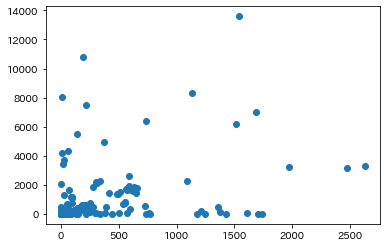

In [147]:
plt.scatter(x='ＳＯ４２−',y='Ｃｌ−',data=df_use)

In [148]:
# PCA: 

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
def pca(df,subset):
    scaler = StandardScaler()
    X_pca = scaler.fit_transform(subset)

    # PCA
    pca = PCA()
    pca.fit(X_pca)

    pcs = pca.transform(X_pca)

    """
    Return DataFrame
    """
    pcs_df = pd.DataFrame(pcs, index=df.index,
                      columns=[f"PC{i+1}" for i in range(pcs.shape[1])])

    explained = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_,
                        columns=subset.columns,
                        index=[f"PC{i+1}" for i in range(len(pca.components_))])
    

    # 累積寄与率を計算
    cumsum = np.cumsum(pca.explained_variance_ratio_)

    # 閾値（例: 90%）を超える最小の成分数を探す
    threshold = 0.90
    d_cumsum = np.argmax(cumsum >= threshold) + 1

    print(f"累積寄与率 {threshold*100}% 基準: {d_cumsum} Components")

    pca_mle = PCA(n_components='mle')
    pca_mle.fit(X_pca)
    d_mle = pca_mle.n_components_
    print(f"MLE法: {d_mle} Components")


    fig,ax = plt.subplots(2,2,figsize=(14,7))
    
    ax[0,0].bar(range(1, 6), pca.explained_variance_ratio_[:5])
    ax[0,0].set_xticks(range(1,9))
    ax[0,0].set_ylabel("Explained variance ratio")
    ax[0,0].set_title("PC1–PC10 Variance Explained")


    
    ax[0,1].plot(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_, marker="o")
    ax[0,1].set_title("Scree Plot (Variance Explained)")
    ax[0,1].set_xlabel("Principal Component")
    ax[0,1].set_ylabel("Variance Ratio")
    ax[0,1].grid(True)
    
    loadings = pd.DataFrame(
    pca.components_,
    columns=subset.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

    
    n_loadings = min(5, len(loadings))
    im = ax[1, 0].imshow(loadings.iloc[:n_loadings], cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
    ax[1, 0].set_title(f"PCA Loadings (Top {n_loadings} PCs)")
    ax[1, 0].set_yticks(range(n_loadings))
    ax[1, 0].set_yticklabels(loadings.index[:n_loadings])
    ax[1, 0].set_xticks(range(len(loadings.columns)))
    ax[1, 0].set_xticklabels(loadings.columns, rotation=90)
    fig.colorbar(im, ax=ax[1, 0], orientation='vertical')



    plt.tight_layout()
    plt.show()


    # (A) 各主成分のZ-score化 (Standardized PC Scores)
    # 主成分スコアを標準偏差(固有値の平方根)で割る
    pc_std_dev = np.sqrt(pca.explained_variance_)
    z_scores_pc = pcs / pc_std_dev

    #z_scores_pc

    t2_scores = np.sum(z_scores_pc ** 2, axis=1) #t2_scores 

    X_recon = pca.inverse_transform(pcs) # 復元
    diff = X_pca - X_recon
    q_statistics = np.sum(diff ** 2, axis=1)


    df_result = subset.copy()
    df_result['PC1'] = pcs[:, 0]
    df_result['PC2'] = pcs[:, 1]
    df_result['PC3'] = pcs[:, 2]
    df_result['PC4'] = pcs[:, 3]
    df_result['PC5'] = pcs[:, 4]


    df_result['PC1_Z'] = z_scores_pc[:, 0] # PC1のZscore
    df_result['PC2_Z'] = z_scores_pc[:, 1] # PC2のZscore
    df_result['PC3_Z'] = z_scores_pc[:, 2]  
    df_result['PC4_Z'] = z_scores_pc[:, 3] 
    df_result['PC5_Z'] = z_scores_pc[:, 4] 


    df_result['T2'] = t2_scores            # 異常度1 (中心からの距離)
    df_result['Q_Stat'] = q_statistics     # 異常度2 (モデルからの乖離)

    print("--- 結果の上位5行 ---")
    print(df_result.head())

    print("\n--- 外れ値箇所のスコア確認 ---")
    print(df_result.tail(2))

    # 各変数がどの程度主成分に寄与しているかどうかをみる
    df_components = pd.DataFrame(
        pca.components_,
        columns=subset.columns,  # 元の変数名リスト
        index=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # print("--- 各主成分への変数の寄与（固有ベクトル） ---")
    # print(df_components)

    return df_result,df_components

In [150]:
df_use.columns

Index(['水源種別', '利用目的', '水温', 'ｐＨ', 'ＮＨ４＋', 'Ｍｇ２＋', 'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−',
       'ＨＣＯ３−', 'ID'],
      dtype='object')

In [151]:
df_use.isna().sum()

水源種別     0
利用目的     0
水温       0
ｐＨ       0
ＮＨ４＋     0
Ｍｇ２＋     0
Ｃａ２＋     0
Ｃｌ−      0
ＳＯ４２−    0
ＨＣＯ３−    0
ID       0
dtype: int64

累積寄与率 90.0% 基準: 5 Components
MLE法: 7 Components


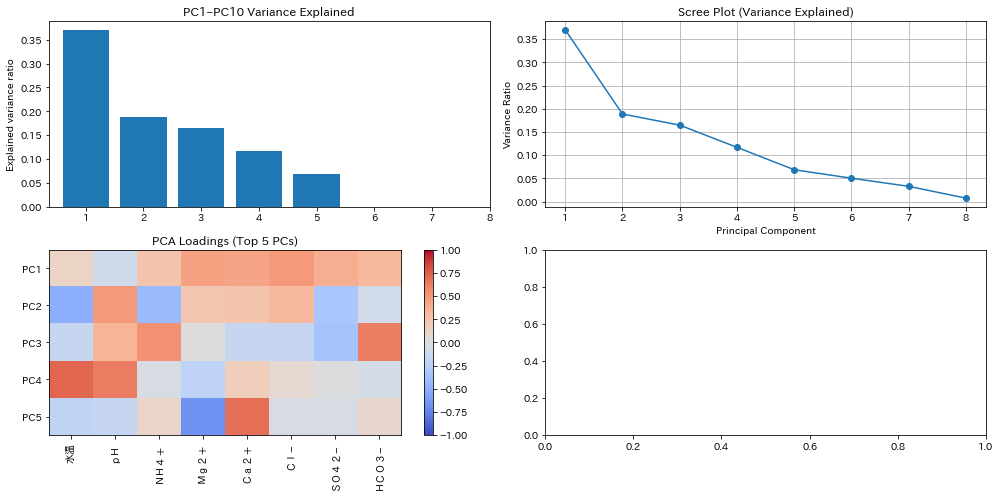

--- 結果の上位5行 ---
     水温   ｐＨ  ＮＨ４＋  Ｍｇ２＋   Ｃａ２＋     Ｃｌ−   ＳＯ４２−  ＨＣＯ３−       PC1       PC2  \
3    48  7.0  0.20  7.65  450.0   194.0  1210.0  204.0  1.589469 -0.461831   
4    67  6.9  0.29  5.95  510.0   163.0  1375.0  170.0  1.926441 -0.881904   
5    35  7.0  0.10  64.5  430.0  1923.0   590.0  538.0  2.094022  0.701237   
6    45  6.7  1.42  53.0  390.0  1705.0   560.0  483.0  1.874779  0.269572   
7  52.5  6.6  1.44  49.0  360.0  1526.0   515.0  446.0  1.687939  0.060482   

        PC3       PC4       PC5     PC1_Z     PC2_Z     PC3_Z     PC4_Z  \
3 -1.258766  0.763210  1.206290  0.922342 -0.375222 -1.094456  0.787618   
4 -1.626831  1.255486  1.298752  1.117882 -0.716516 -1.414477  1.295637   
5 -0.286273  0.257575  0.705795  1.215126  0.569731 -0.248905  0.265812   
6 -0.348462  0.378369  0.659544  1.087903  0.219018 -0.302976  0.390469   
7 -0.390087  0.511337  0.555562  0.979483  0.049140 -0.339168  0.527689   

      PC5_Z         T2        Q_Stat  
3  1.623598  22.511962  4

In [152]:
subset = df_use[['水温', 'ｐＨ', 'ＮＨ４＋', 'Ｍｇ２＋', 'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−',
       'ＨＣＯ３−']]

df_result, df_components= pca(df_use,subset)

In [153]:
# Parallel Analysis: 
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import PCA

def parallel_analysis(X, n_iter=1000, percentile=95):
    n, p = X.shape
    pca = PCA()
    pca.fit(X)
    ev_real = pca.explained_variance_

    ev_rand = np.zeros((n_iter, p))

    for i in tqdm(range(n_iter), desc="Parallel Analysis"):
        X_rand = np.random.normal(size=(n, p))
        pca.fit(X_rand)
        ev_rand[i] = pca.explained_variance_

    ev_rand_percentile = np.percentile(ev_rand, percentile, axis=0)
    return ev_real, ev_rand_percentile


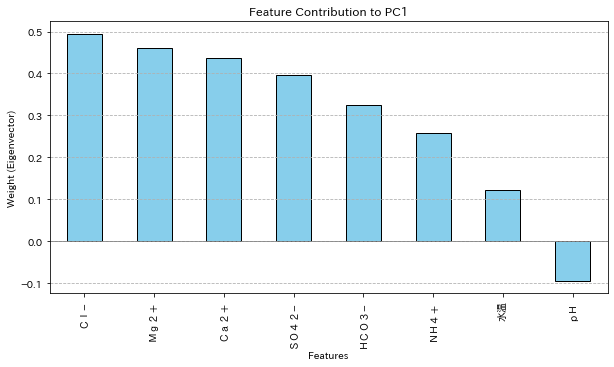

In [154]:
"""
PCごとのデータを取り出す
"""

# PC1のデータを取り出す
pc1_weights = df_components.loc['PC1']
# 寄与度の絶対値でソートして棒グラフにする（影響力が強い順）
# abs()をつけるかどうかは目的によりますが、ここでは「影響の強さ」を見るため絶対値でソート
pc1_weights_sorted = pc1_weights.abs().sort_values(ascending=False)
# ※ グラフ描画時は元の符号(正負)を残して表示するのが一般的です
pc1_weights_plot = pc1_weights[pc1_weights_sorted.index]

plt.figure(figsize=(10, 5))
pc1_weights_plot.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Contribution to PC1')
plt.xlabel('Features')
plt.ylabel('Weight (Eigenvector)')
plt.axhline(0, color='grey', linewidth=0.8) # 0のライン
plt.grid(axis='y', linestyle='--')
plt.show()

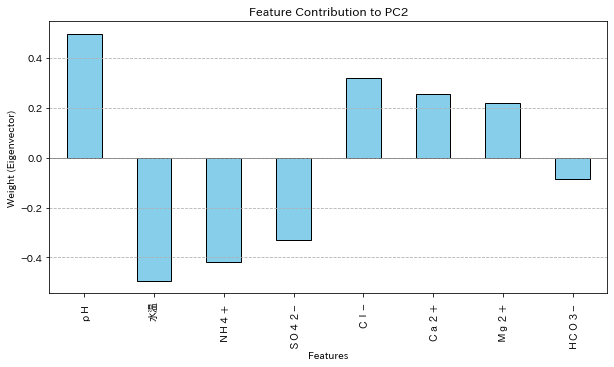

In [155]:
"""
PCごとのデータを取り出す
"""

# PC1のデータを取り出す
pc1_weights = df_components.loc['PC2']
# 寄与度の絶対値でソートして棒グラフにする（影響力が強い順）
# abs()をつけるかどうかは目的によりますが、ここでは「影響の強さ」を見るため絶対値でソート
pc1_weights_sorted = pc1_weights.abs().sort_values(ascending=False)
# ※ グラフ描画時は元の符号(正負)を残して表示するのが一般的です
pc1_weights_plot = pc1_weights[pc1_weights_sorted.index]

plt.figure(figsize=(10, 5))
pc1_weights_plot.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Contribution to PC2')
plt.xlabel('Features')
plt.ylabel('Weight (Eigenvector)')
plt.axhline(0, color='grey', linewidth=0.8) # 0のライン
plt.grid(axis='y', linestyle='--')
plt.show()

In [156]:
# Rador Chart 
def plot_multi_pc_radar(loadings, pcs):
    labels = loadings.columns.tolist()
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    for pc in pcs:
        values = loadings.loc[pc].values
        values = np.concatenate([values, [values[0]]])
        ax.plot(angles, values, label=pc, linewidth=2)
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_ylim(-1, 1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    ax.set_title("PCA Loadings Radar Chart")

    plt.show()


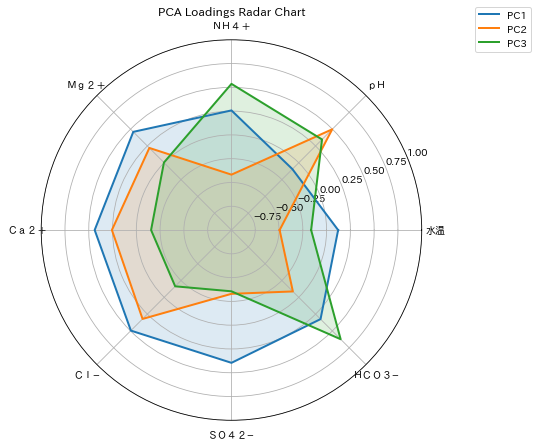

In [157]:
plot_multi_pc_radar(df_components, ["PC1", "PC2","PC3"])


In [158]:
# それぞれの温泉地がどの範囲に分布しているか見たい：　クラスター作り
# PC成分ごとの分布を見るなど

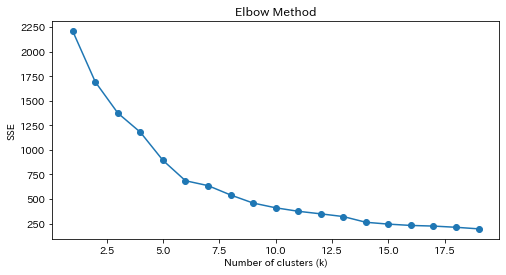

In [213]:
# Kmeans:
from sklearn.cluster import KMeans
X = subset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---------------------------
# 2. エルボー法で最適な k を探す
# ---------------------------
sse = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_) # SSE（誤差）を保存

# エルボー法のグラフ描画
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

In [214]:
from sklearn.cluster import KMeans
from tqdm import tqdm

def gap_statistic(
    X,
    ks=range(2, 11),
    n_refs=10,
    random_state=42
):
    gaps = []
    sks = []

    # データ範囲（PC空間）
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    for k in tqdm(ks, desc="Gap statistic"):
        # 実データ
        km = KMeans(n_clusters=k, n_init=5, random_state=random_state)
        km.fit(X)
        disp = km.inertia_

        # 参照データ
        ref_disps = np.zeros(n_refs)
        for i in range(n_refs):
            X_ref = np.random.uniform(mins, maxs, size=X.shape)
            km.fit(X_ref)
            ref_disps[i] = km.inertia_

        gap = np.mean(np.log(ref_disps)) - np.log(disp)
        sk = np.sqrt(1 + 1/n_refs) * np.std(np.log(ref_disps))

        gaps.append(gap)
        sks.append(sk)

    return np.array(gaps), np.array(sks)


Gap statistic: 100%|██████████| 18/18 [00:02<00:00,  7.53it/s]


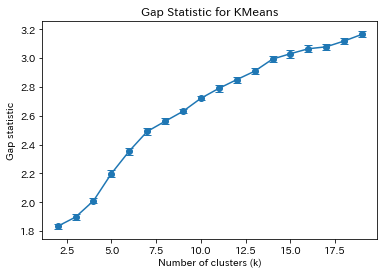

In [215]:
ks = range(2, 20)
gaps, sks = gap_statistic(X, ks, n_refs=20)

plt.errorbar(
    ks, gaps, yerr=sks,
    marker='o', capsize=4
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Gap statistic")
plt.title("Gap Statistic for KMeans")
plt.show()


In [231]:
from mpl_toolkits.mplot3d import Axes3D  # 3D描画用
optimal_k = 6
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)

# 新しいカテゴリー（クラスター番号）を作成
df_result['Cluster_ID'] = kmeans_final.fit_predict(X)

In [232]:
df_result

,水温,ｐＨ,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,PC1,PC2,...,PC4,PC5,PC1_Z,PC2_Z,PC3_Z,PC4_Z,PC5_Z,T2,Q_Stat,Cluster_ID
3,48,7.0,0.20,7.65,450.00,194.00,1210.00,204.0,1.589469,-0.461831,...,0.763210,1.206290,0.922342,-0.375222,-1.094456,0.787618,1.623598,22.511962,4.580054e-30,4
4,67,6.9,0.29,5.95,510.00,163.00,1375.00,170.0,1.926441,-0.881904,...,1.255486,1.298752,1.117882,-0.716516,-1.414477,1.295637,1.748047,30.058441,7.244398e-30,4
5,35,7.0,0.10,64.5,430.00,1923.00,590.00,538.0,2.094022,0.701237,...,0.257575,0.705795,1.215126,0.569731,-0.248905,0.265812,0.949959,6.595884,3.134163e-30,4
6,45,6.7,1.42,53.0,390.00,1705.00,560.00,483.0,1.874779,0.269572,...,0.378369,0.659544,1.087903,0.219018,-0.302976,0.390469,0.887708,5.173443,2.853759e-30,4
7,52.5,6.6,1.44,49.0,360.00,1526.00,515.00,446.0,1.687939,0.060482,...,0.511337,0.555562,0.979483,0.049140,-0.339168,0.527689,0.747755,5.068252,2.257382e-30,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,21,6.6,0.45,98,233.00,4180.00,10.00,67.0,1.600169,1.648474,...,-0.366558,-0.310270,0.928551,1.339328,-0.497404,-0.378280,-0.417605,10.798733,2.062286e-30,4
469,14.5,6.35,0.01,14.8,54.80,18.20,74.90,3.1,-0.681674,0.309521,...,-0.669572,0.088723,-0.395564,0.251475,-0.193747,-0.690985,0.119416,1.309999,3.137340e-31,3
474,18,7.8,0.01,6.6,6.30,1.80,1.90,5.23,-1.006952,0.709407,...,0.033371,-0.169601,-0.584318,0.576368,0.184452,0.034438,-0.228274,1.367976,1.242610e-30,3
477,13.5,6.25,0.01,9.09,9.48,4.88,15.40,1.78,-0.888186,0.256407,...,-0.757335,0.009545,-0.515400,0.208322,-0.133623,-0.781555,0.012847,1.016985,7.588164e-31,3


In [233]:
# クラスターごとの平均値を計算
cluster_features = df_result.groupby('Cluster_ID')[subset.columns].mean()

# 見やすくするために表示
print("Cluster Profiles (Mean PC Scores):")
print(cluster_features)

Cluster Profiles (Mean PC Scores):
                   水温        ｐＨ       ＮＨ４＋        Ｍｇ２＋        Ｃａ２＋  \
Cluster_ID                                                           
0           82.688636  7.907273   4.082273    2.302955   30.272500   
1                23.7       7.2   5.202857       259.2  862.600000   
2             81.3375  2.429375   9.200000   17.834375   50.395000   
3           17.779096  6.805311   0.994243    6.002203   17.867345   
4           45.041379  6.752069   1.770345    56.32931  389.579310   
5           40.833333  6.863333  78.466667  181.433333  242.000000   

                    Ｃｌ−        ＳＯ４２−        ＨＣＯ３−  
Cluster_ID                                         
0            486.073409   177.774773    86.659091  
1           8810.542857   788.571429   245.914286  
2            425.437500  1071.562500      1.14375  
3             71.852203    24.509774   103.542034  
4           2055.634483   595.910345   558.434483  
5           2289.333333   666.333333  31

In [234]:
cluster_features.columns

Index(['水温', 'ｐＨ', 'ＮＨ４＋', 'Ｍｇ２＋', 'Ｃａ２＋', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−'], dtype='object')

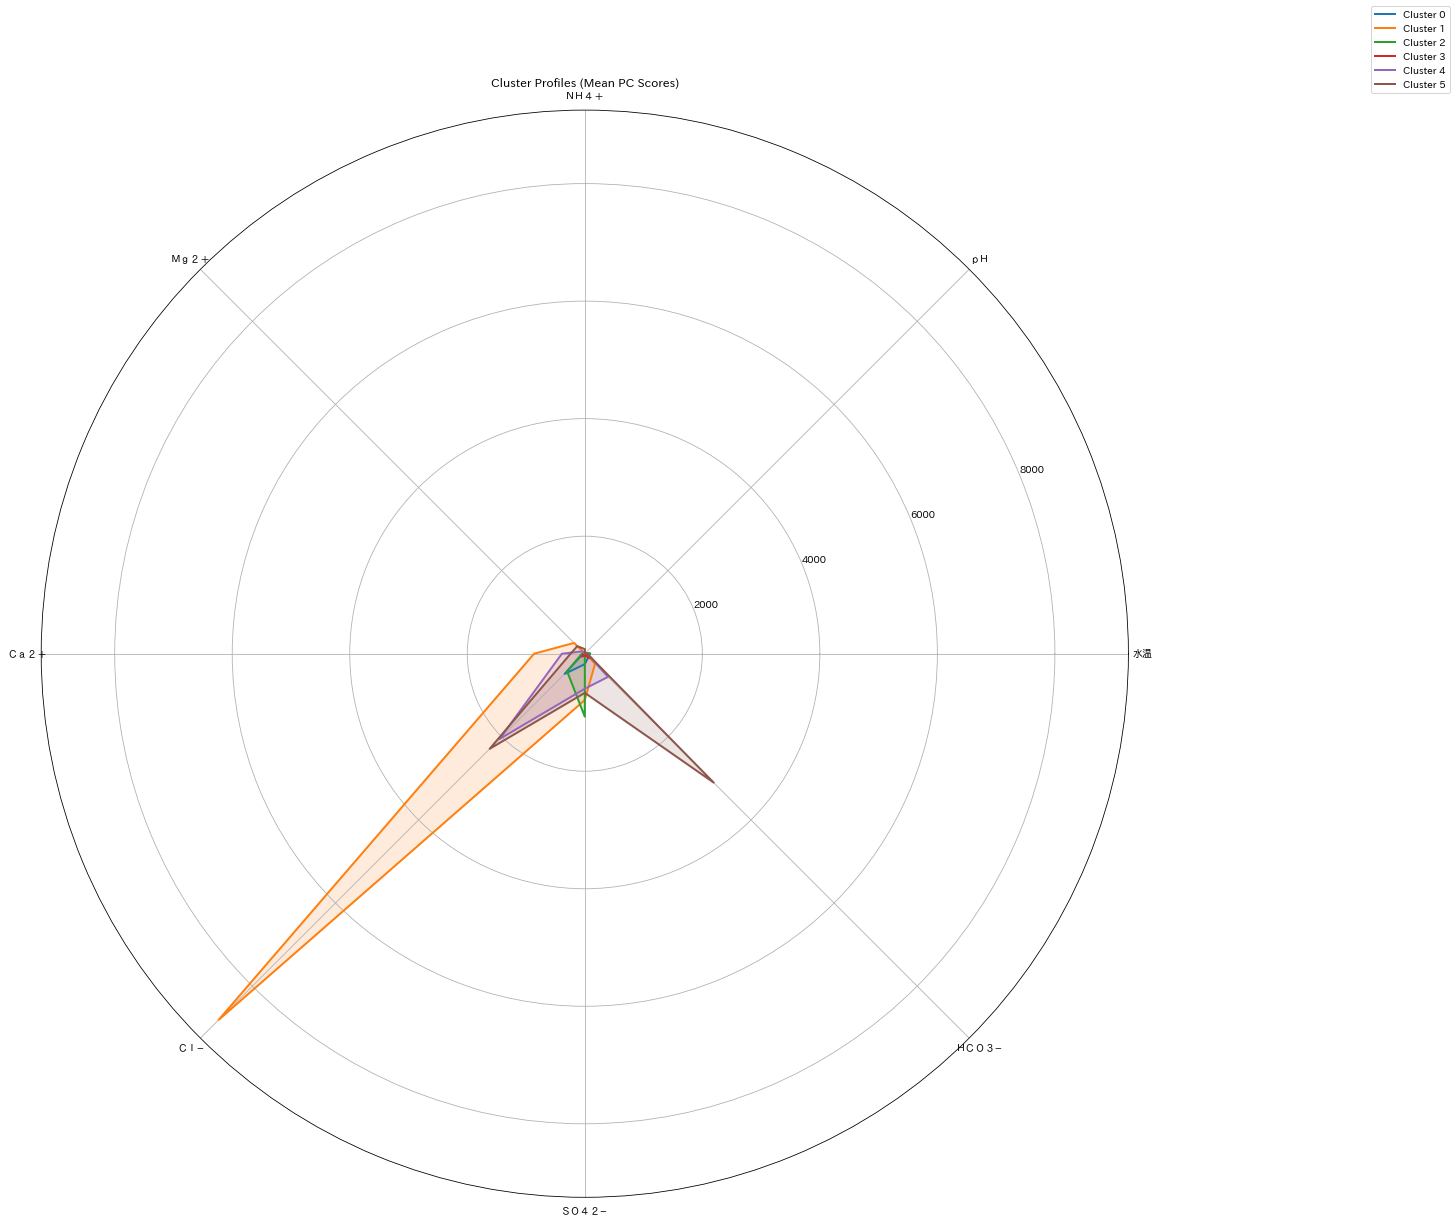

In [235]:


def plot_cluster_radar(cluster_features):
    labels = cluster_features.columns.tolist()  # ['PC1','PC2','PC3']
    
    num_vars = len(labels)

    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig, ax = plt.subplots(figsize=(20,20), subplot_kw=dict(polar=True))

    for cluster in cluster_features.index:
        values = cluster_features.loc[cluster].values
        values = np.concatenate([values, [values[0]]])

        ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster}")
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title("Cluster Profiles (Mean PC Scores)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    # PCはZスコア空間なので0基準線が重要
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')

    plt.show()


plot_cluster_radar(cluster_features)



In [165]:
df_use

,水源種別,利用目的,水温,ｐＨ,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,ID
3,湧泉,温泉・鉱泉,48,7.0,0.20,7.65,450.00,194.00,1210.00,204.0,140.0_53.0_20.0_39.0_12.0_40.0_3
4,井戸,温泉・鉱泉,67,6.9,0.29,5.95,510.00,163.00,1375.00,170.0,140.0_53.0_20.0_39.0_12.0_40.0_4
5,湧泉,温泉・鉱泉,35,7.0,0.10,64.5,430.00,1923.00,590.00,538.0,140.0_53.0_20.0_39.0_12.0_40.0_5
6,湧泉,温泉・鉱泉,45,6.7,1.42,53.0,390.00,1705.00,560.00,483.0,140.0_53.0_20.0_39.0_12.0_40.0_6
7,湧泉,温泉・鉱泉,52.5,6.6,1.44,49.0,360.00,1526.00,515.00,446.0,140.0_53.0_20.0_39.0_12.0_40.0_7
...,...,...,...,...,...,...,...,...,...,...,...
416,坑道,坑道湧水,21,6.6,0.45,98,233.00,4180.00,10.00,67.0,nan_nan_nan_nan_nan_nan_416
469,井戸,用水,14.5,6.35,0.01,14.8,54.80,18.20,74.90,3.1,nan_nan_nan_nan_nan_nan_469
474,井戸,用水,18,7.8,0.01,6.6,6.30,1.80,1.90,5.23,nan_nan_nan_nan_nan_nan_474
477,井戸,用水,13.5,6.25,0.01,9.09,9.48,4.88,15.40,1.78,nan_nan_nan_nan_nan_nan_477


In [166]:
df_result
df_resulttomerge = df_result['Cluster_ID']

In [167]:
DATASET = pd.merge(df_use,df_resulttomerge,on=df_use.index)

In [168]:
DATASET

,key_0,水源種別,利用目的,水温,ｐＨ,ＮＨ４＋,Ｍｇ２＋,Ｃａ２＋,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,ID,Cluster_ID
0,3,湧泉,温泉・鉱泉,48,7.0,0.20,7.65,450.00,194.00,1210.00,204.0,140.0_53.0_20.0_39.0_12.0_40.0_3,7
1,4,井戸,温泉・鉱泉,67,6.9,0.29,5.95,510.00,163.00,1375.00,170.0,140.0_53.0_20.0_39.0_12.0_40.0_4,7
2,5,湧泉,温泉・鉱泉,35,7.0,0.10,64.5,430.00,1923.00,590.00,538.0,140.0_53.0_20.0_39.0_12.0_40.0_5,0
3,6,湧泉,温泉・鉱泉,45,6.7,1.42,53.0,390.00,1705.00,560.00,483.0,140.0_53.0_20.0_39.0_12.0_40.0_6,0
4,7,湧泉,温泉・鉱泉,52.5,6.6,1.44,49.0,360.00,1526.00,515.00,446.0,140.0_53.0_20.0_39.0_12.0_40.0_7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,474,井戸,用水,18,7.8,0.01,6.6,6.30,1.80,1.90,5.23,nan_nan_nan_nan_nan_nan_474,1
290,474,井戸,用水,18,7.8,0.01,6.6,6.30,1.80,1.90,5.23,nan_nan_nan_nan_nan_nan_474,1
291,477,井戸,用水,13.5,6.25,0.01,9.09,9.48,4.88,15.40,1.78,nan_nan_nan_nan_nan_nan_477,1
292,478,井戸,用水,20.5,7.68,0.01,10.3,1.91,1.26,0.63,4.97,nan_nan_nan_nan_nan_nan_478,1


In [180]:
tomerge = DATASET[['ID','Cluster_ID']]
tomerge_unique = tomerge.drop_duplicates(subset=['ID'])
FINAL = pd.merge(df, tomerge_unique, on='ID', how='left')  # left merge で df の行数維持


In [193]:
len(tomerge_unique),len(df)

(276, 4082)

In [194]:
FINAL

,都道府県名,所在地,東経（゜）,東経（′）,東経（″),北緯（゜）,北緯（′）,北緯（″),標高（ｍ）,水源種別,...,free H2S,free CO2,T-CO2,T-As,T-Hg,T-P,T-B,Ｅｈ,ID,Cluster_ID
0,岩手県,盛岡市南方約8km,NaN,NaN,NaN,NaN,NaN,NaN,NaN,井戸,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan_nan_nan_nan_nan_nan_0,NaN
1,岩手県,NaN,140.0,53.0,20.0,39.0,12.0,40.0,650.0,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_53.0_20.0_39.0_12.0_40.0_1,NaN
2,岩手県,NaN,140.0,46.0,30.0,38.0,58.0,40.0,NaN,湧泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_46.0_30.0_38.0_58.0_40.0_2,NaN
3,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,650.0,湧泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_53.0_20.0_39.0_12.0_40.0_3,7.0
4,岩手県,和賀郡和賀町岩崎新田,140.0,53.0,20.0,39.0,12.0,40.0,650.0,井戸,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_53.0_20.0_39.0_12.0_40.0_4,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,福島県,福島県いわき市渡辺町,140.0,49.0,11.0,36.0,57.0,27.0,NaN,湧泉,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_49.0_11.0_36.0_57.0_27.0_719,NaN
4078,福島県,福島県いわき市泉町下川,140.0,50.0,41.0,36.0,56.0,29.0,NaN,井戸,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_50.0_41.0_36.0_56.0_29.0_720,NaN
4079,福島県,福島県いわき市泉町下川畑中,140.0,51.0,40.0,36.0,56.0,31.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_51.0_40.0_36.0_56.0_31.0_721,NaN
4080,福島県,福島県いわき市泉町下皮大畑,140.0,51.0,59.0,36.0,55.0,3.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0_51.0_59.0_36.0_55.0_3.0_722,NaN


In [195]:
len(FINAL),len(df)

(4082, 4082)

In [196]:
len(FINAL)-len(FINAL[FINAL['Cluster_ID'].isna()])

381